In [4]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


In [5]:
# BasicData  
# - R0 : Euclidean initial distance from target
# - NTrials : number of agents initialized

import numpy as np

Nagents = 4 # NTrials : number of agents initialized
R0 = 30 # Euclidean distance from target
V = .7 # Linear speed of the agents

# Determine domain of motion of the agent
RMIN = 1 # Minimal distance with respect to prey
TMAX = 20*np.pi*(R0) # Maximum time allowed for the simulation
dt = 0.1 # Time steps for time integration
e3 = np.array([0,0,1]) # Orientation of symmetry axis of source flow
AntennaeLength = .1  # Distance between sensors
BodyWidth = .1 # 

# Define information flow 
Grads = [GradientStresslet] # ShearStresslet, GradientStresslet, ShearStokeslet, 
GradName = ['GradientStresslet'] # 'ShearStresslet', 'GradientStresslet', 'ShearStokeslet', 

#Twist setting
twists = [0.0, 0.3] # Imposed twist

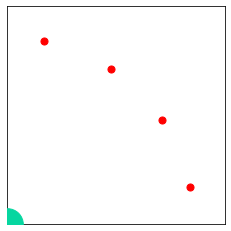

In [6]:
# Plot scheme A, plot the scheme A in Fig.3 

fig = plt.figure()
ax = fig.add_subplot(111)

# Set agent positions
Thetas = np.linspace(0.2, np.pi/2-0.2, Nagents)
phi = np.zeros(Nagents)
AgentPosition = R0*np.array([np.sin(Thetas)*np.cos(phi), np.sin(Thetas)*np.sin(phi), np.cos(Thetas)]).T.reshape((Nagents,3))

# Plots
ax.scatter(0.0, 0.0, s=1000, marker='o', color = '#06d6a0', zorder = 3)
ax.scatter(AgentPosition[:,0], AgentPosition[:,2], s=50 ,marker='o', c='red')


ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim([0, R0 + 5])
ax.set_ylim([0, R0 + 5])
ax.set_aspect('equal',adjustable='box')

# Uncomment to save
# plt.savefig("Scheme_A_Fig3.png", bbox_inches = 'tight')

plt.show()

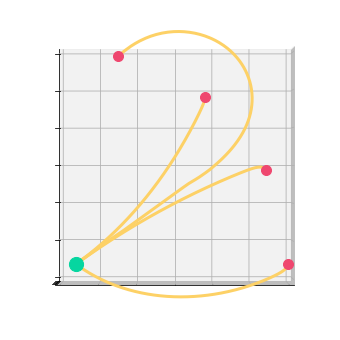

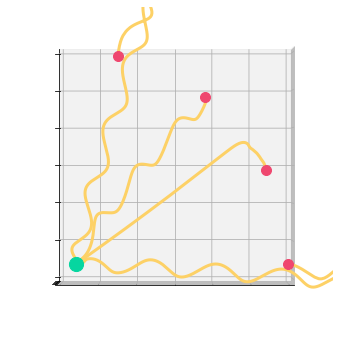

In [7]:
# Code to Evolve and plot the trajectories in 3D
# It calculates evolution for both strategies: Braitenberg and Triangulation
#


from matplotlib.patches import Circle
import mpl_toolkits.mplot3d.art3d as art3d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Realize Evolution
Strategies = [Evolution_Triangulation]  # Evolution_Braitenberg ,Evolution_Triangulation
StrategyName = "T" # "B", "T"

for strat_i, Strategy in enumerate(Strategies):
    for grad_i, Grad in enumerate(Grads):
        for twist in twists:
            Trajectories_x, Trajectories_y, Trajectories_z, Successes = Evolution(Grad, Strategy, twist)

            fig = plt.figure(figsize=(6, 6))
            ax = fig.add_subplot(111, projection='3d')



            for a in range(Nagents):
                ax.plot(Trajectories_x[a], Trajectories_y[a], Trajectories_z[a], color='#fdd166', alpha=1, linewidth= 3)	
                ax.scatter(Trajectories_x[a][0], Trajectories_y[a][0], Trajectories_z[a][0], color='#ef476f', s= 100)	
            ax.scatter(0,0,0, s=200, marker='o', color = '#06d6a0')#, label='Target')
            ax.set_xlim([-2, R0])
            ax.set_ylim([-2, 2])
            ax.set_zlim([0., R0])
            xticks = np.linspace(-2, R0, 7)
            yticks = np.linspace(-2, 2, 4)
            zticks = np.linspace(-2, R0, 7)

            empty_labels_x = ["" for i in range(7)]
            empty_labels_y = ["" for i in range(4)]
            empty_labels_z = ["" for i in range(7)]

            ax.set_xticks(xticks, empty_labels_x)
            ax.set_yticks(yticks, empty_labels_y)
            ax.set_zticks(zticks, empty_labels_z)


            ax.set_box_aspect(aspect = (1, .2, 1))
            ax.view_init(0, 270)
            # ax.set_title(StrategyName[strat_i])

            # Uncomment to save
            # plt.savefig("PlotPaper/Traj"+str(twist)+"_"+StrategyName+".png")
            plt.show()


In [14]:
from chart_studio import plotly as py
import plotly.graph_objs as go

data = [go.Streamtube(
    x = Trajectories_x,
    y = Trajectories_y,
    z = Trajectories_z,
    u = Trajectories_x,
    v = Trajectories_y,
    w = Trajectories_z,
    sizeref = 0.25,
    colorscale = 'Greens', 
    cmin = 0,
    cmax = 3
    )
]

layout = go.Layout(
    scene = dict(
      camera = dict(
        eye = dict(
          x = -0.7243612458865182,
          y = 1.9269804254717962,
          z = 0.6704828299861716
        )
      )
    )
)

fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='streamtube-basic')

KeyboardInterrupt: 